# Feature Collinearity Analysis

This notebook evaluates collinearity among model features for the regridded dataset.

It includes:
- Pairwise correlation matrix
- Variance Inflation Factor (VIF)
- Condition number and eigenvalue diagnostics
- High-correlation feature pair report

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_style('darkgrid')
%matplotlib inline

In [2]:
DATA_PATH = Path('../output/station_data_grid_5x5.csv')
FEATURE_COLS = ['climo_temp', 'climo_humidity', 'Abs_Latitude', 'Longitude', 'Elevation', 'station_count']
HIGH_CORR_THRESHOLD = 0.8

print(f'Data path: {DATA_PATH.resolve()}')
print(f'Feature set: {FEATURE_COLS}')

Data path: /net/fs06/d3/gretar/bc3_urop/output/station_data_grid_5x5.csv
Feature set: ['climo_temp', 'climo_humidity', 'Abs_Latitude', 'Longitude', 'Elevation', 'station_count']


In [3]:
df = pd.read_csv(DATA_PATH)
df['Abs_Latitude'] = df['Latitude'].abs()

missing = [c for c in FEATURE_COLS if c not in df.columns]
if missing:
    raise ValueError(f'Missing required feature columns: {missing}')

X = df[FEATURE_COLS].dropna().copy()
print(f'Rows in raw file: {len(df)}')
print(f'Rows used after dropping NA in features: {len(X)}')
X.head()

Rows in raw file: 673
Rows used after dropping NA in features: 598


,climo_temp,climo_humidity,Abs_Latitude,Longitude,Elevation,station_count
11,6.736994,75.225000,53.000,-70.9670,37.0,1
12,6.989042,72.170833,53.230,-68.7895,20.3,2
16,13.159973,49.891667,45.783,-67.5000,58.0,1
19,10.020309,83.183333,46.417,168.3330,2.0,1
20,10.838073,78.000000,45.900,170.5200,2.0,1


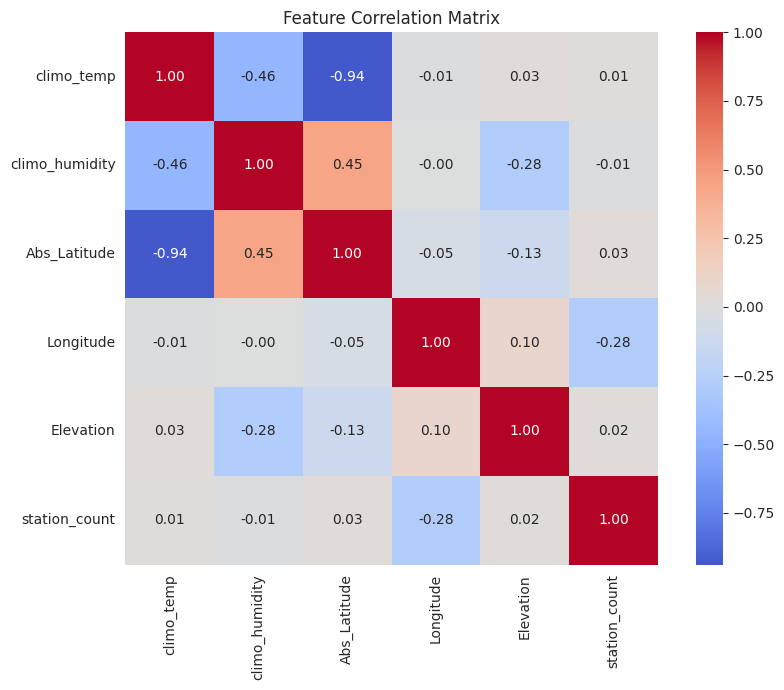

,climo_temp,climo_humidity,Abs_Latitude,Longitude,Elevation,station_count
climo_temp,1.000000,-0.458417,-0.938228,-0.013222,0.028621,0.009111
climo_humidity,-0.458417,1.000000,0.446447,-0.000188,-0.281295,-0.008735
Abs_Latitude,-0.938228,0.446447,1.000000,-0.045912,-0.127266,0.028818
Longitude,-0.013222,-0.000188,-0.045912,1.000000,0.097446,-0.277525
Elevation,0.028621,-0.281295,-0.127266,0.097446,1.000000,0.019245
station_count,0.009111,-0.008735,0.028818,-0.277525,0.019245,1.000000


In [4]:
corr = X.corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

corr

In [5]:
corr_abs = corr.abs().copy()
upper_triangle = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
high_pairs = (
    upper_triangle.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'abs_corr'})
    .sort_values('abs_corr', ascending=False)
)

high_pairs = high_pairs[high_pairs['abs_corr'] >= HIGH_CORR_THRESHOLD]

if high_pairs.empty:
    print(f'No feature pairs with |corr| >= {HIGH_CORR_THRESHOLD}.')
else:
    print(f'Feature pairs with |corr| >= {HIGH_CORR_THRESHOLD}:')
    display(high_pairs)

Feature pairs with |corr| >= 0.8:


,feature_1,feature_2,abs_corr
2,climo_temp,Abs_Latitude,0.938228


In [6]:
vif_df = pd.DataFrame()
vif_df['feature'] = X.columns
vif_df['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]
vif_df = vif_df.sort_values('VIF', ascending=False).reset_index(drop=True)

print('VIF interpretation guide:')
print('- VIF < 5: usually acceptable')
print('- 5 to 10: moderate concern')
print('- > 10: high collinearity concern')

vif_df

VIF interpretation guide:
- VIF < 5: usually acceptable
- 5 to 10: moderate concern
- > 10: high collinearity concern


,feature,VIF
0,climo_humidity,24.984915
1,Abs_Latitude,19.041657
2,climo_temp,3.687189
3,station_count,1.368996
4,Elevation,1.267089
5,Longitude,1.223332


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

u, s, vt = np.linalg.svd(X_scaled, full_matrices=False)
condition_number = s.max() / s.min()
eigenvalues = np.linalg.eigvalsh(np.cov(X_scaled, rowvar=False))

print(f'Condition number (standardized X): {condition_number:.2f}')
print('Rule of thumb: >30 suggests notable multicollinearity; >100 is severe.')
print('\nEigenvalues (ascending):')
print(np.round(np.sort(eigenvalues), 6))

Condition number (standardized X): 6.53
Rule of thumb: >30 suggests notable multicollinearity; >100 is severe.

Eigenvalues (ascending):
[0.054055 0.566683 0.716786 1.074707 1.29043  2.30739 ]


In [8]:
summary = vif_df.copy()
summary['vif_flag'] = np.where(summary['VIF'] > 10, 'high', np.where(summary['VIF'] >= 5, 'moderate', 'low'))

print('Collinearity summary by feature:')
display(summary)

if (summary['VIF'] > 10).any():
    print('Recommendation: Consider dropping/combining highly collinear features or using regularization.')
else:
    print('Recommendation: No severe VIF-based collinearity detected.')

Collinearity summary by feature:


,feature,VIF,vif_flag
0,climo_humidity,24.984915,high
1,Abs_Latitude,19.041657,high
2,climo_temp,3.687189,low
3,station_count,1.368996,low
4,Elevation,1.267089,low
5,Longitude,1.223332,low


Recommendation: Consider dropping/combining highly collinear features or using regularization.
